In [5]:
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt


In [14]:
datos_penguins = pd.read_csv('../../data/raw/penguins.csv')
datos_penguins = datos_penguins.dropna()

Que preguntas me hago respecto a esto?
- Los pinguinos estan en todas las islas? O las especies residen en islas en particular?
- Hay diferencias en las cualidades fisicas entre los pinguinos femenino y masculino de las especies?
- Se relaciona en algo el lugar donde fueron tomadas las mediciones, con su tamaño?
- Los pinguinos, se mueven entre estas islas? Es decir, las mediciones, si hubieran sido tomadas al dia siguiente, puede un pinguino haber estado en otra de estas islas? O son inaccesibles entre si?

In [13]:
categoricas = datos_penguins.select_dtypes(include=['object', 'category'])
categoricas.value_counts()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_12612\303131875.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = datos_penguins.select_dtypes(include=['object', 'category'])


species    island     sex   
Gentoo     Biscoe     Male      61
                      Female    58
Chinstrap  Dream      Female    34
                      Male      34
Adelie     Dream      Male      28
                      Female    27
           Torgersen  Female    24
                      Male      23
           Biscoe     Female    22
                      Male      22
Name: count, dtype: int64

Las razas Gento y Chinstrap aparecen en una sola isla. La raza Adelie es la unica que aparece en la isla Torgensen, por lo que es un buen atributo para identificar varios ejemplares.

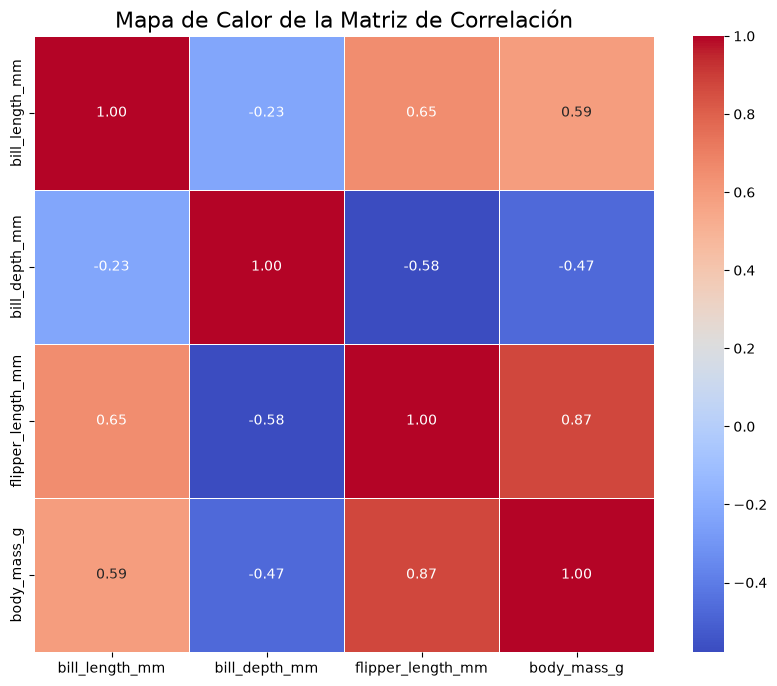

In [17]:
# Calcular la matriz de correlación
matriz_corr = datos_penguins.select_dtypes(include=['float64', 'int64']).corr()

# Visualización con Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Mapa de Calor de la Matriz de Correlación', fontsize=16)
plt.show()

Esta matriz tiene sentido en algun aspecto: el largo de las aletas esta bastante relacionado con todas las variables: "Pinguino mas grande -> todo mas grande", pero las variables referidas al pico, a simple vista puedo pensar que alguna especie tenga un pico mas chico en relacion.

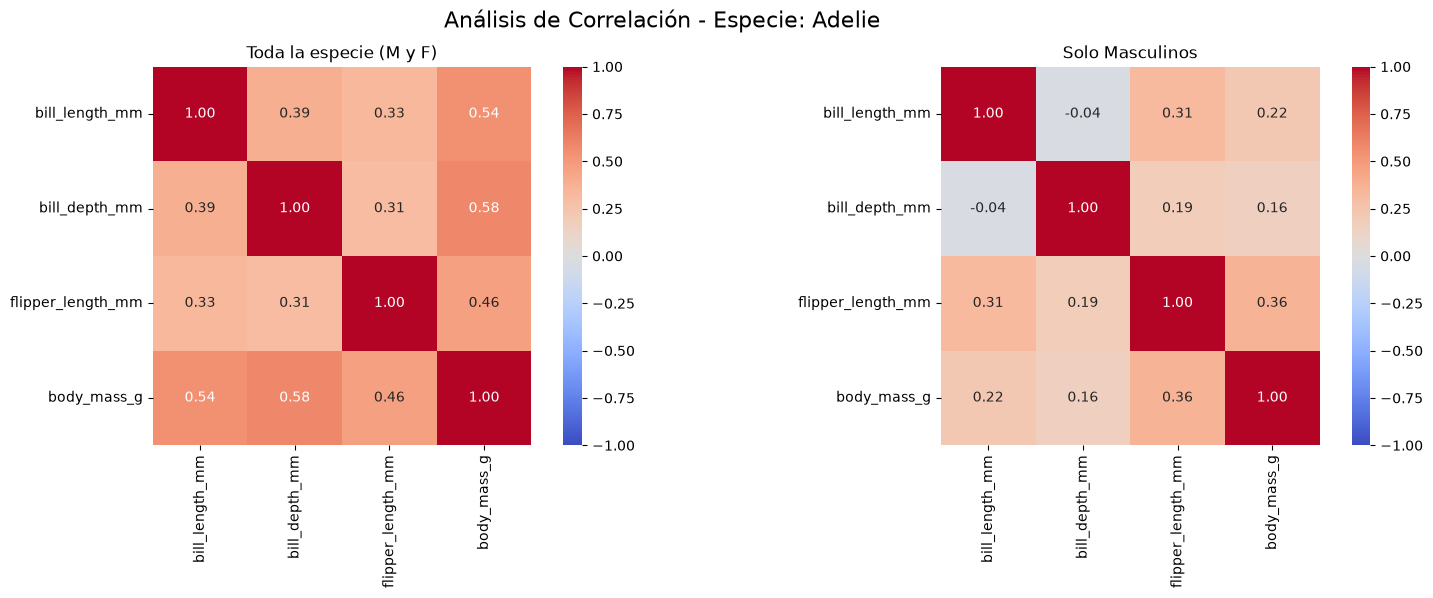

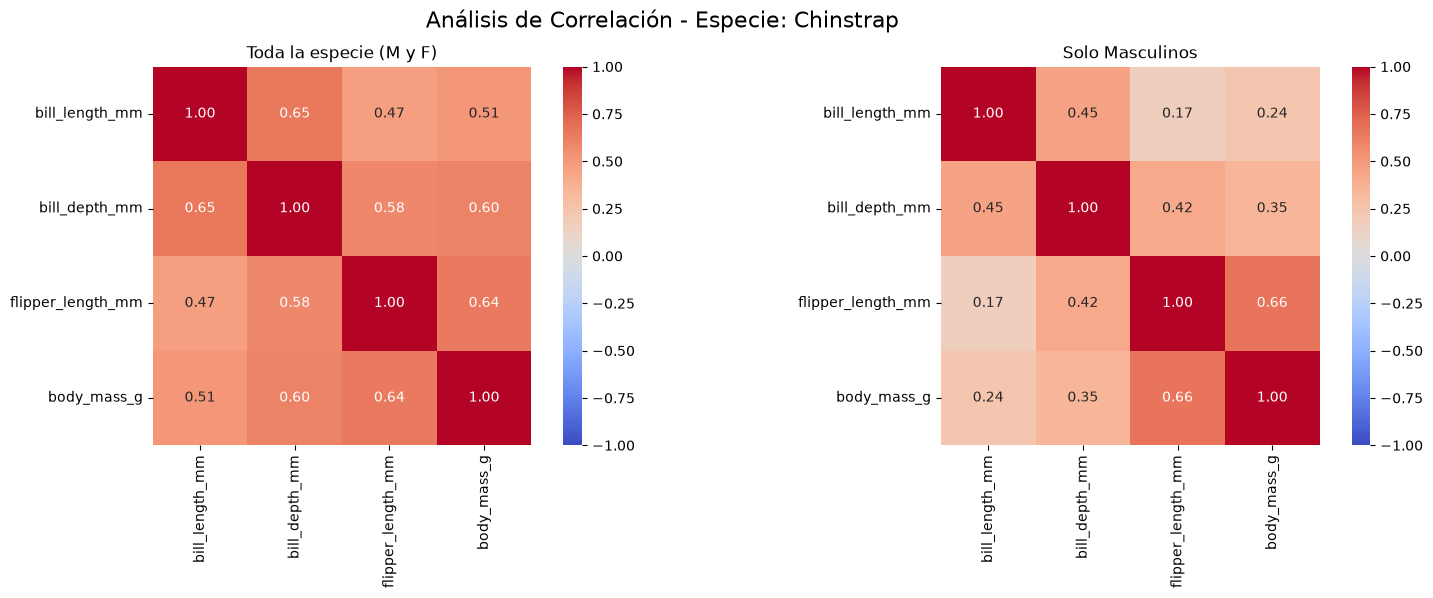

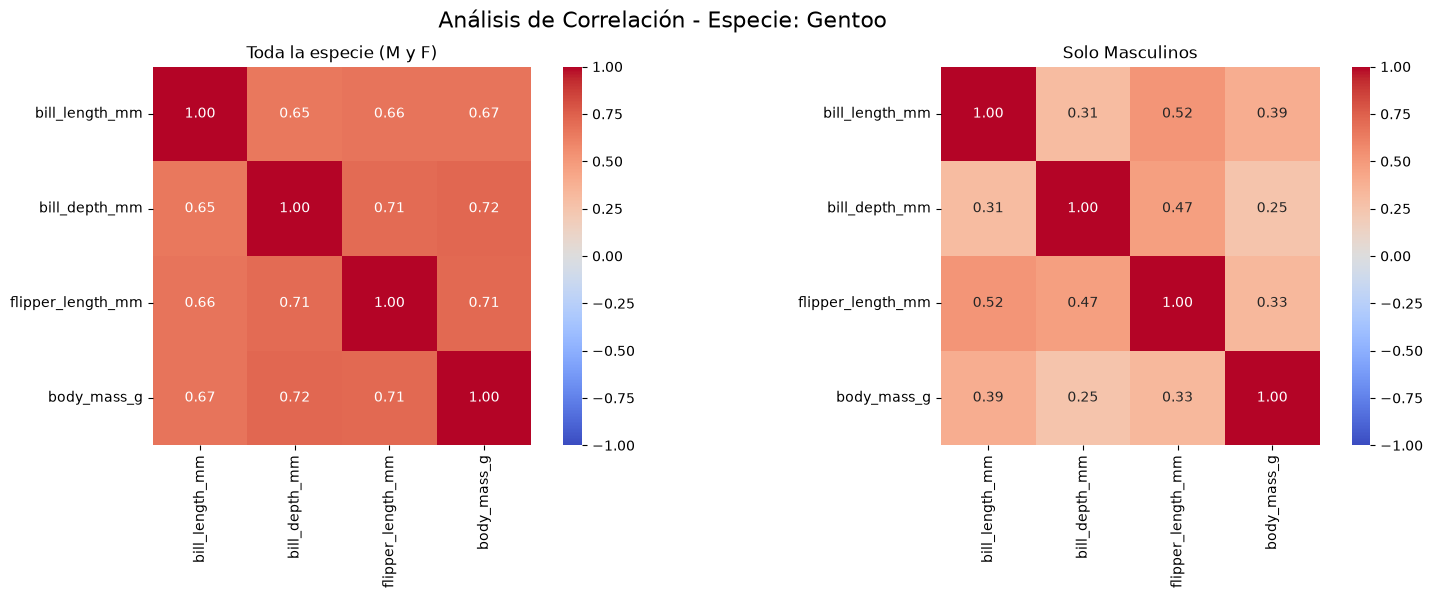

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Se obtienen las especies únicas del dataset
especies = datos_penguins['species'].unique()

for especie in especies:
    # 1. Configurar la figura con 1 fila y 2 columnas
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f"Análisis de Correlación - Especie: {especie}", fontsize=16)
    
    # ==========================================
    # GRÁFICO 1: Toda la especie (Izquierda)
    # ==========================================
    df_especie = datos_penguins[datos_penguins['species'] == especie]
    num_especie = df_especie.select_dtypes(include=[np.number])
    matriz_total = num_especie.corr()
    
    sns.heatmap(matriz_total, 
                annot=True, 
                fmt=".2f", 
                cmap="coolwarm", 
                vmin=-1, vmax=1, 
                square=True,
                ax=axes[0]) # Se asigna al primer eje
    axes[0].set_title("Toda la especie (M y F)")
    
    # ==========================================
    # GRÁFICO 2: Subsegmentación - Solo Masculinos (Derecha)
    # ==========================================
    df_masculino = df_especie[df_especie['sex'] == 'Male']
    num_masculino = df_masculino.select_dtypes(include=[np.number])
    matriz_masculino = num_masculino.corr()
    
    sns.heatmap(matriz_masculino, 
                annot=True, 
                fmt=".2f", 
                cmap="coolwarm", 
                vmin=-1, vmax=1, 
                square=True,
                ax=axes[1]) # Se asigna al segundo eje
    axes[1].set_title("Solo Masculinos")
    
    # Ajustar el diseño para que no se superpongan los textos
    plt.tight_layout()
    plt.show()

No termino descubriendo nada, por especie, se ven variables relacionadas positivamente, todas con valores similares -> A mas grande algo, mas grande las demas caracteristicas por especie

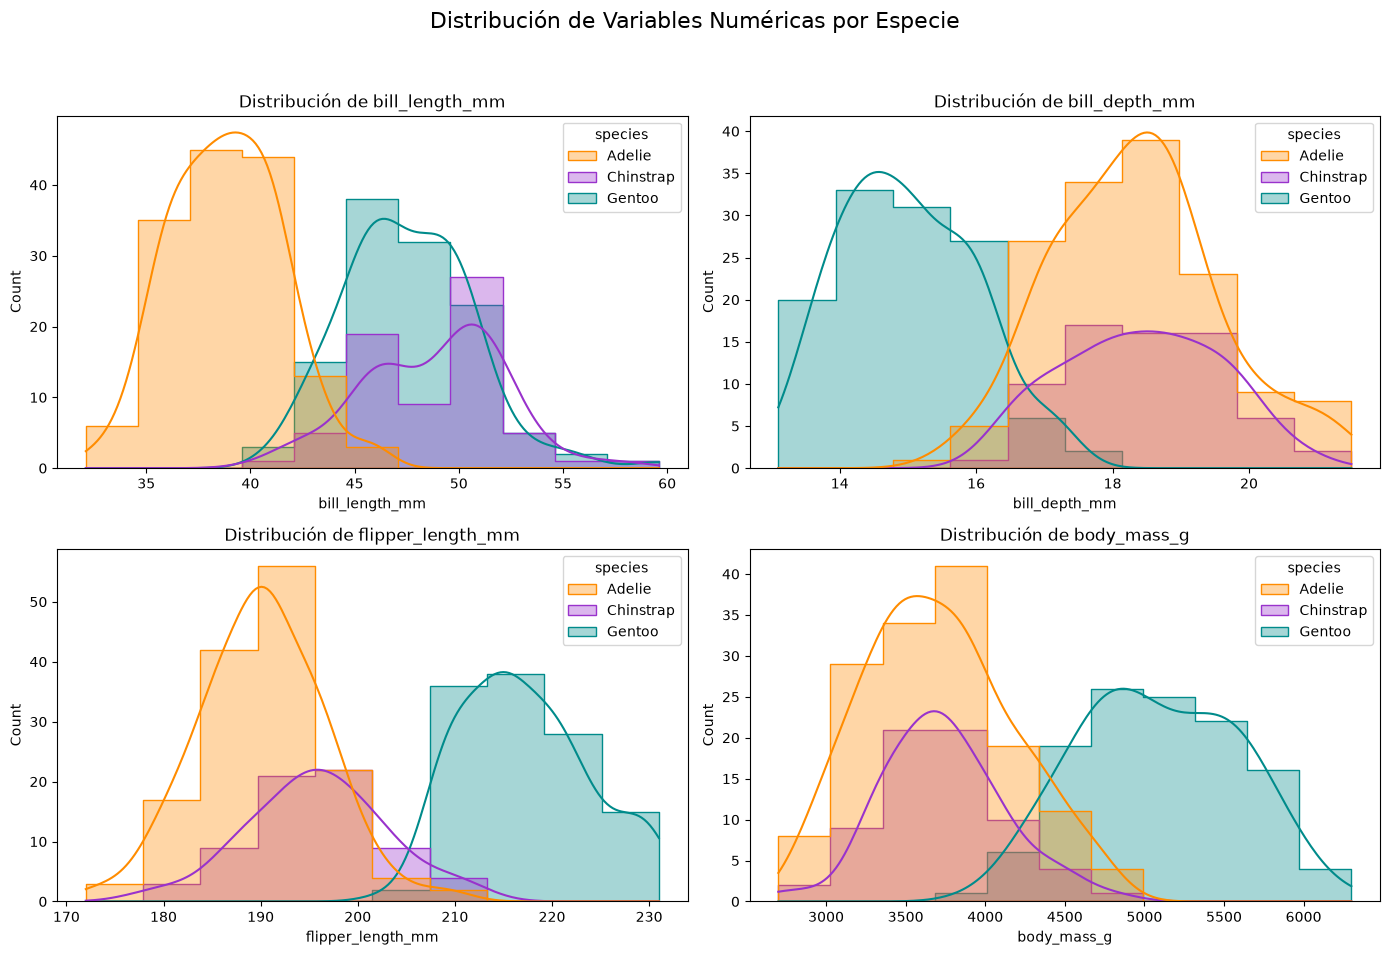

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

columnas_numericas = datos_penguins.select_dtypes(include=['float64', 'int64']).columns

# Paleta específica de alto contraste y balance estético
paleta_penguins = {'Adelie': '#FF8C00', 'Chinstrap': '#9932CC', 'Gentoo': '#008B8B'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribución de Variables Numéricas por Especie', fontsize=16)

for i, col in enumerate(columnas_numericas):
    ax = axes[i // 2, i % 2]
    
    sns.histplot(
        data=datos_penguins,
        x=col,
        hue='species',
        kde=True,
        ax=ax,
        palette=paleta_penguins,
        alpha=0.35,
        element="step",       # Delinea los bordes evitando que las barras se tapen
        common_norm=False     # Normaliza la densidad de cada especie de forma independiente
    )
    ax.set_title(f'Distribución de {col}')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Aca podemos ver mejor en comparacion a los graficos univariados! Vemos que la especie Gentoo es la que estaba generando las colas pesadas, debido a que tiene un numero similar de muestras que la Adelie, y son bastantes separables por el tamaño de los pinguinos en general! (Mas peso, mayor tamaño de aleta, y largo de pico), peeeero, tiene una peculiaridad: el alto de su pico es mas corto, por lo que me imagino una especie de pinguino con un pico mas "alapisado".

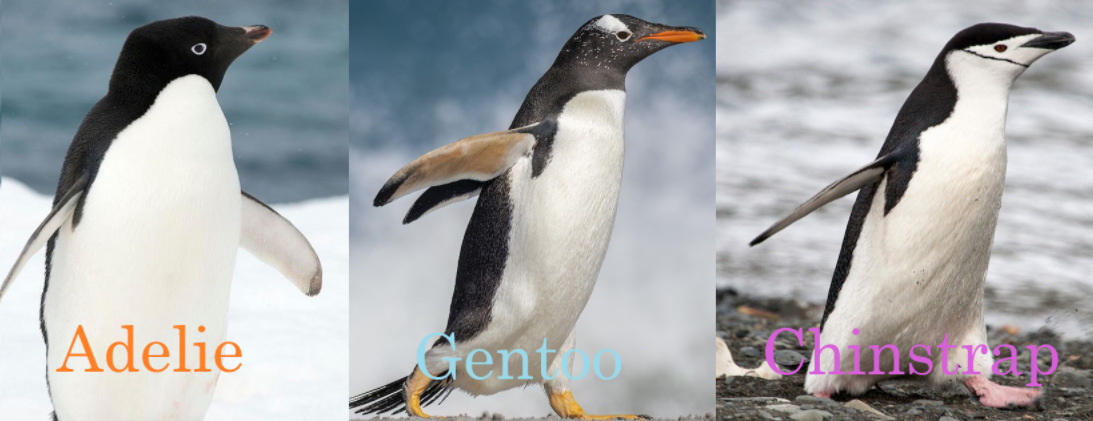

Efectivamente!! Son pinguinos mas grandotes, con el pico un poco mas fino y largo. Ademas, al ver la foto, pienso que hay una correlacion similar en el crecimiento entre las 2 variables relacionadas al pico en las especies de Gentoo y Chinstrap, que al ver el grafico de correlaciones se da! (0,65 para ambas)

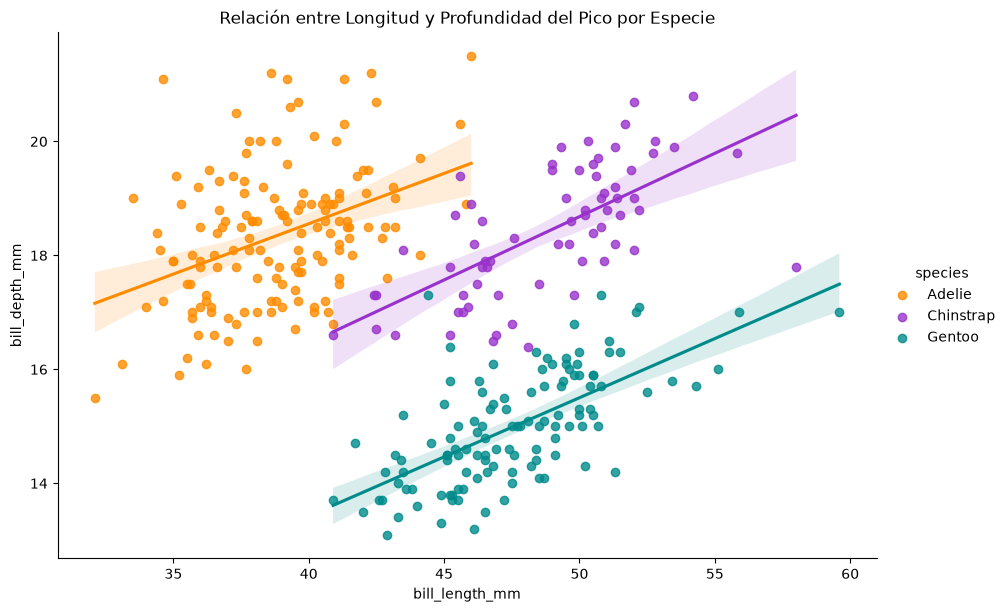

Ecuaciones de regresión y Coeficiente de Determinación (R²):
Adelie:
  y = 0.1767x + (11.4877)
  R² = 0.1489 (r = 0.3858, p-valor = 1.515e-06)

Chinstrap:
  y = 0.2222x + (7.5691)
  R² = 0.4271 (r = 0.6535, p-valor = 1.526e-09)

Gentoo:
  y = 0.2076x + (5.1210)
  R² = 0.4277 (r = 0.6540, p-valor = 7.337e-16)



In [22]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import linregress

# 1. Definición de la paleta personalizada
paleta_penguins = {'Adelie': '#FF8C00', 'Chinstrap': '#9932CC', 'Gentoo': '#008B8B'}

# 2. Generación del gráfico lmplot
sns.lmplot(
    data=datos_penguins,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="species",
    palette=paleta_penguins,
    height=6,
    aspect=1.5
)

plt.title("Relación entre Longitud y Profundidad del Pico por Especie")
plt.show()

# 3. Cálculo de la ecuación de la recta (y = mx + b) y R² mediante linregress
print("Ecuaciones de regresión y Coeficiente de Determinación (R²):")

for especie in datos_penguins['species'].dropna().unique():
    df_filtrado = datos_penguins[datos_penguins['species'] == especie].dropna(subset=['bill_length_mm', 'bill_depth_mm'])
    
    x = df_filtrado['bill_length_mm']
    y = df_filtrado['bill_depth_mm']
    
    # linregress calcula pendiente (slope), intersección (intercept) y rvalue
    regresion = linregress(x, y)
    m = regresion.slope
    b = regresion.intercept
    r2 = regresion.rvalue**2
    p_val = regresion.pvalue
    
    print(f"{especie}:")
    print(f"  y = {m:.4f}x + ({b:.4f})")
    print(f"  R² = {r2:.4f} (r = {regresion.rvalue:.4f}, p-valor = {p_val:.3e})\n")

In [23]:
from scipy.stats import pearsonr

# Filtrar para una especie (ej. Adelie)
adelie = datos_penguins[datos_penguins['species'] == 'Adelie'].dropna()

# Calcular Pearson entre largo de aleta y masa corporal
coef, p_valor = pearsonr(adelie['flipper_length_mm'], adelie['body_mass_g'])

print(f"Coeficiente de correlación (r): {coef:.3f}")
print(f"P-valor: {p_valor:.3e}")

Coeficiente de correlación (r): 0.465
P-valor: 3.402e-09


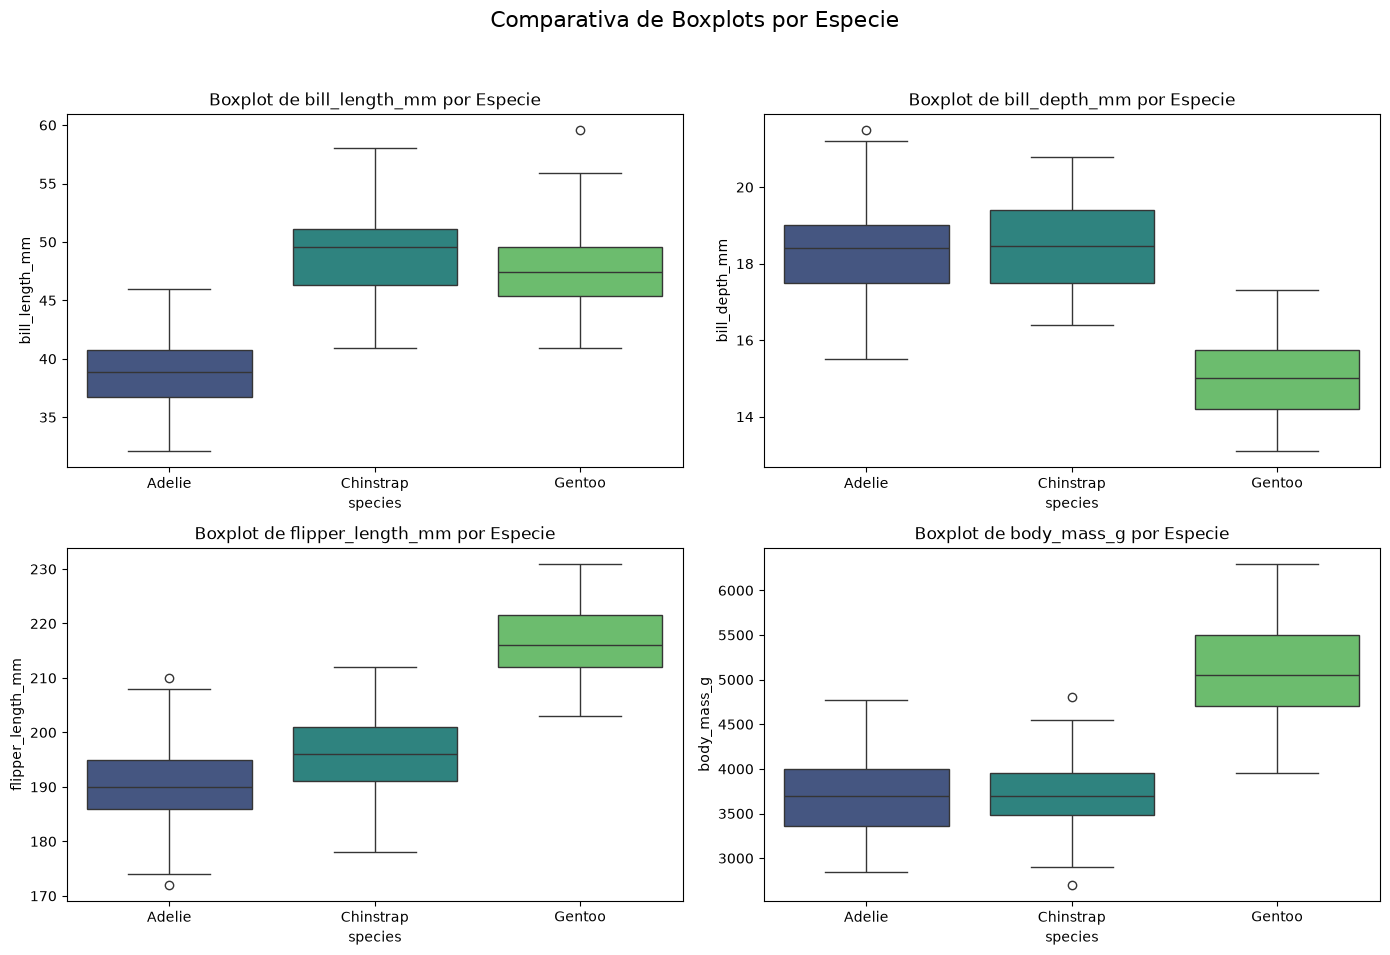

In [9]:
# Boxplots segmentados por especie
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Comparativa de Boxplots por Especie', fontsize=16)

for i, col in enumerate(columnas_numericas):
    sns.boxplot(data=datos_penguins, x='species', y=col, hue='species', ax=axes[i//2, i%2], palette='viridis', legend=False)
    axes[i//2, i%2].set_title(f'Boxplot de {col} por Especie')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [10]:
import pandas as pd

# Crear tabla de contingencia entre especie e isla
tabla_especie_isla = pd.crosstab(datos_penguins['species'], datos_penguins['island'], margins=True)

print("Tabla de Contingencia: Especie vs Isla")
display(tabla_especie_isla)

Tabla de Contingencia: Especie vs Isla


island,Biscoe,Dream,Torgersen,All
species,,,,
Adelie,44,55,47,146
Chinstrap,0,68,0,68
Gentoo,119,0,0,119
All,163,123,47,333


In [11]:
# También podemos ver la asociación entre especie y sexo
tabla_especie_sexo = pd.crosstab(datos_penguins['species'], datos_penguins['sex'])

print("\nTabla de Contingencia: Especie vs Sexo")
display(tabla_especie_sexo)


Tabla de Contingencia: Especie vs Sexo


sex,Female,Male
species,,
Adelie,73,73
Chinstrap,34,34
Gentoo,58,61
